# 📊 Leitura e Plots de Dados Já Tratados (Silver)

Notebook focado **somente na pasta chulha**:
- usa os módulos `dataprep.py` e `plot_utils.py`;
- lê apenas dados já tratados de `chulha/data/silver`;
- plota exemplos rápidos para inspeção.

In [7]:
from pathlib import Path
import sys
import io
import contextlib
import pandas as pd
import matplotlib.pyplot as plt

# Descobrir base da pasta chulha
cwd = Path.cwd().resolve()
if cwd.name == 'chulha':
    BASE_CHULHA = cwd
elif (cwd / 'chulha').exists():
    BASE_CHULHA = (cwd / 'chulha').resolve()
else:
    raise FileNotFoundError('Execute em chulha/ ou no diretório pai que contém chulha/.')

if str(BASE_CHULHA) not in sys.path:
    sys.path.insert(0, str(BASE_CHULHA))

from dataprep import DataLoader
from plot_utils import PlotterGFET

print(f'✅ BASE_CHULHA: {BASE_CHULHA}')

✅ BASE_CHULHA: /home/v/Documents/contas/chulha


In [8]:
# Caminho único de dados tratados dentro de chulha
base_silver = BASE_CHULHA / 'data' / 'silver'
if not base_silver.exists():
    raise FileNotFoundError(f'Pasta não encontrada: {base_silver}')

print(f'✅ Pasta silver: {base_silver}')

✅ Pasta silver: /home/v/Documents/contas/chulha/data/silver


In [9]:
# Selecionar experimento e subpasta automaticamente
experimentos = sorted([p for p in base_silver.iterdir() if p.is_dir()])
if not experimentos:
    raise FileNotFoundError(f'Nenhum experimento encontrado em {base_silver}')

experimento = experimentos[0]
subpastas = sorted([p for p in experimento.iterdir() if p.is_dir()])
pasta_dados = subpastas[0] if subpastas else experimento

print(f'📅 Experimento selecionado: {experimento.name}')
print(f'📂 Pasta de dados: {pasta_dados}')

📅 Experimento selecionado: 19abr
📂 Pasta de dados: /home/v/Documents/contas/chulha/data/silver/19abr/19abr_curves


In [10]:
# Carregar dados e mapear tudo que existe (chips, etapas e devices)
loader = DataLoader(str(pasta_dados))
chips = loader.listar_chips_disponiveis()
if not chips:
    raise FileNotFoundError(f'Nenhum arquivo *_ajustado.csv encontrado em {pasta_dados}')

resumo = []
dados_por_chip = {}
for ch in chips:
    # Evitar poluição de print do carregar_chip durante o mapeamento
    with contextlib.redirect_stdout(io.StringIO()):
        dados_chip = loader.carregar_chip(ch)
    dados_por_chip[ch] = dados_chip

    etapas_chip = sorted(list(dados_chip.keys()))
    devices_chip = loader.obter_colunas_disponiveis(dados_chip)
    resumo.append({
        'chip': ch,
        'n_etapas': len(etapas_chip),
        'n_devices': len(devices_chip),
        'etapas': ', '.join(etapas_chip) if etapas_chip else '(sem etapas)'
    })

df_resumo = pd.DataFrame(resumo).sort_values(['n_etapas', 'n_devices'], ascending=False).reset_index(drop=True)
print('📋 Mapeamento disponível na pasta selecionada:')
display(df_resumo)

etapas_preferidas = ['bare', 'etoh', 'ddt', 'pbse', 'apt', 'eta']
chip = None
for ch in chips:
    etapas_chip = set(dados_por_chip[ch].keys())
    if any(e in etapas_chip for e in etapas_preferidas):
        chip = ch
        break

if chip is None:
    chip = chips[0]

dados = dados_por_chip[chip]
devices = loader.obter_colunas_disponiveis(dados)
etapas_plot = [e for e in etapas_preferidas if e in dados]
if not etapas_plot:
    etapas_plot = list(dados.keys())

print(f'\n🔬 Chip selecionado para os exemplos: {chip}')
print(f'📈 Etapas que serão usadas no plot: {etapas_plot}')
print(f'🎯 Devices disponíveis: {len(devices)}')

📋 Mapeamento disponível na pasta selecionada:


,chip,n_etapas,n_devices,etapas
0,C3,13,20,"apt, b1, b2, b3, c100ng, c25ng, c50ng, c75ng, ..."
1,C4,9,20,"apt, b1, b2, c25ng, c50ng, c75ng, eta, etoh, pbse"
2,C1,4,20,"c25ng, menos12, menos15, menos18"
3,C2,4,20,"b3, ddt, eta, pbse"
4,C5,1,20,bare



🔬 Chip selecionado para os exemplos: C2
📈 Etapas que serão usadas no plot: ['ddt', 'pbse', 'eta']
🎯 Devices disponíveis: 20


In [15]:
# Construir DF executável (long/tidy) a partir de TODOS os chips mapeados
registros = []
for chip_nome, dados_chip in dados_por_chip.items():
    for etapa_nome, df_etapa in dados_chip.items():
        if 'V_G' not in df_etapa.columns:
            continue

        colunas_devices = [c for c in df_etapa.columns if c != 'V_G']
        if not colunas_devices:
            continue

        bloco = df_etapa.melt(
            id_vars='V_G',
            value_vars=colunas_devices,
            var_name='device',
            value_name='I_DS'
        ).copy()
        bloco['chip'] = chip_nome
        bloco['etapa'] = etapa_nome
        registros.append(bloco)

if not registros:
    raise ValueError('Não foi possível montar o df_exec a partir do mapeamento.')

df_exec = pd.concat(registros, ignore_index=True)
df_exec['device'] = df_exec['device'].astype(str)
df_exec['V_G'] = pd.to_numeric(df_exec['V_G'], errors='coerce')
df_exec['I_DS'] = pd.to_numeric(df_exec['I_DS'], errors='coerce')
df_exec = df_exec.dropna(subset=['V_G', 'I_DS']).reset_index(drop=True)

print(f'✅ df_exec criado: {df_exec.shape[0]:,} linhas x {df_exec.shape[1]} colunas')
display(df_exec.head())

df_exec_resumo = (
    df_exec.groupby('chip')
    .agg(
        n_etapas=('etapa', 'nunique'),
        n_devices=('device', 'nunique'),
        n_pontos=('I_DS', 'size')
    )
    .sort_values(['n_etapas', 'n_devices', 'n_pontos'], ascending=False)
    .reset_index()
)
print('📊 Resumo do df_exec por chip:')
display(df_exec_resumo)

def _ordenar_devices(lista_devices):
    return sorted(lista_devices, key=lambda x: (len(str(x)), str(x)))

def df_para_dados_plot(df_base, chip_sel, etapas_sel=None):
    df_chip = df_base[df_base['chip'] == chip_sel].copy()
    if df_chip.empty:
        return {}

    if etapas_sel is None:
        etapas_sel = sorted(df_chip['etapa'].unique().tolist())

    dados_plot = {}
    for etapa in etapas_sel:
        df_etapa = df_chip[df_chip['etapa'] == etapa]
        if df_etapa.empty:
            continue

        pivot = (
            df_etapa.pivot_table(
                index='V_G',
                columns='device',
                values='I_DS',
                aggfunc='mean'
            )
            .reset_index()
            .sort_values('V_G')
            .reset_index(drop=True)
        )
        pivot.columns.name = None
        cols = ['V_G'] + _ordenar_devices([c for c in pivot.columns if c != 'V_G'])
        dados_plot[etapa] = pivot[cols]

    return dados_plot

✅ df_exec criado: 299,460 linhas x 5 colunas


,V_G,device,I_DS,chip,etapa
0,-0.465920,1,2.417768e-07,C1,menos18
1,-0.463917,1,2.413626e-07,C1,menos18
2,-0.461913,1,2.409317e-07,C1,menos18
3,-0.459909,1,2.404842e-07,C1,menos18
4,-0.457905,1,2.400199e-07,C1,menos18


📊 Resumo do df_exec por chip:


,chip,n_etapas,n_devices,n_pontos
0,C3,13,20,125580
1,C4,9,20,86940
2,C1,4,20,38640
3,C2,4,20,38640
4,C5,1,20,9660


## DataFrame estruturado para execução dos plots

A partir do mapeamento (`dados_por_chip`), criamos um DataFrame único (`df_exec`) no formato *long/tidy* com colunas:

- `chip`
- `etapa`
- `V_G`
- `device`
- `I_DS`

Com ele, conseguimos reconstruir os dicionários por etapa e executar os mesmos plots de forma padronizada.

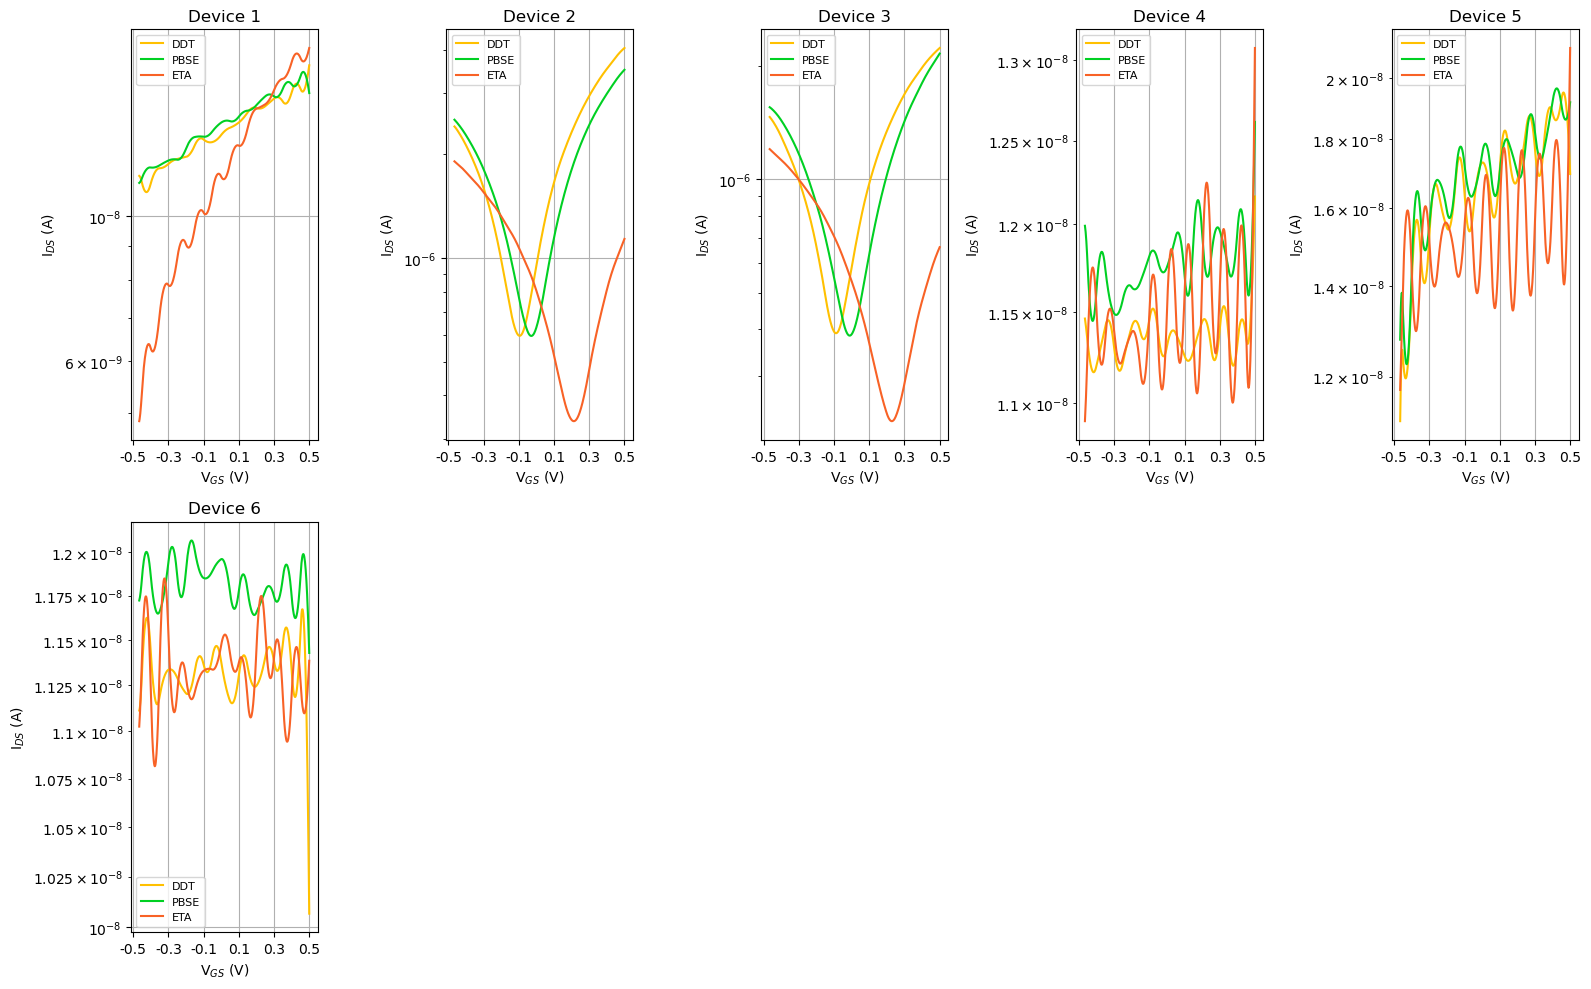

In [16]:
# Exemplo 1: Grid de transferência usando df_exec
plotter = PlotterGFET(chip_name=chip)

if not etapas_plot:
    raise ValueError('Nenhuma etapa disponível para plotar no chip selecionado.')

dados_plot_chip = df_para_dados_plot(df_exec, chip_sel=chip, etapas_sel=etapas_plot)
if not dados_plot_chip:
    raise ValueError('Não foi possível reconstruir dados de plot a partir do df_exec.')

etapa_ref = list(dados_plot_chip.keys())[0]
devices_disponiveis_plot = [c for c in dados_plot_chip[etapa_ref].columns if c != 'V_G']
devices_plot = devices_disponiveis_plot[:min(6, len(devices_disponiveis_plot))]
if not devices_plot:
    raise ValueError('Nenhum device disponível para plotar no chip selecionado.')

fig = plotter.plot_curvas_transferencia_grid(
    dados=dados_plot_chip,
    etapas=list(dados_plot_chip.keys()),
    figsize=(16, 10),
    devices=devices_plot
)
plt.show()

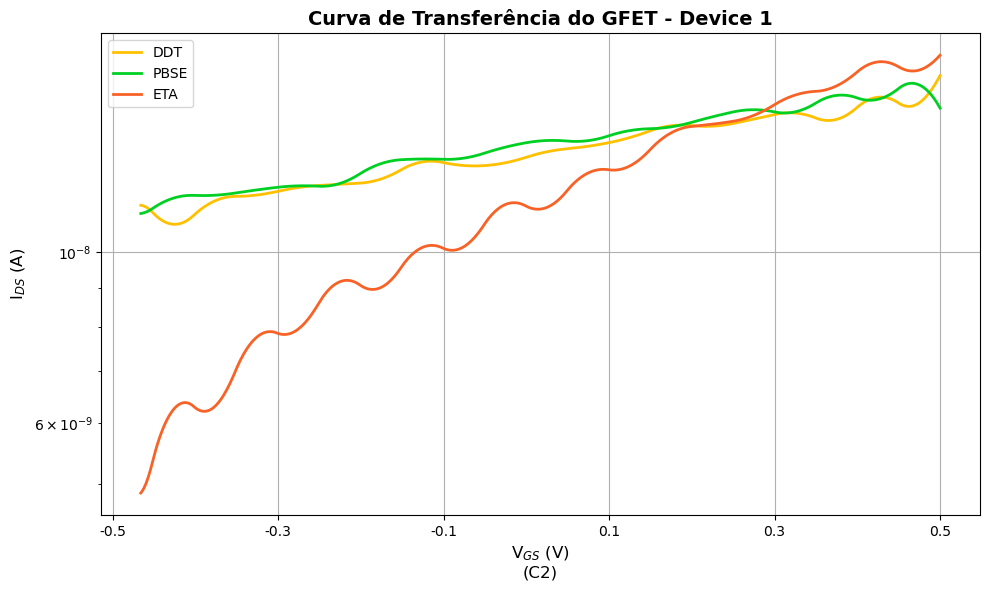

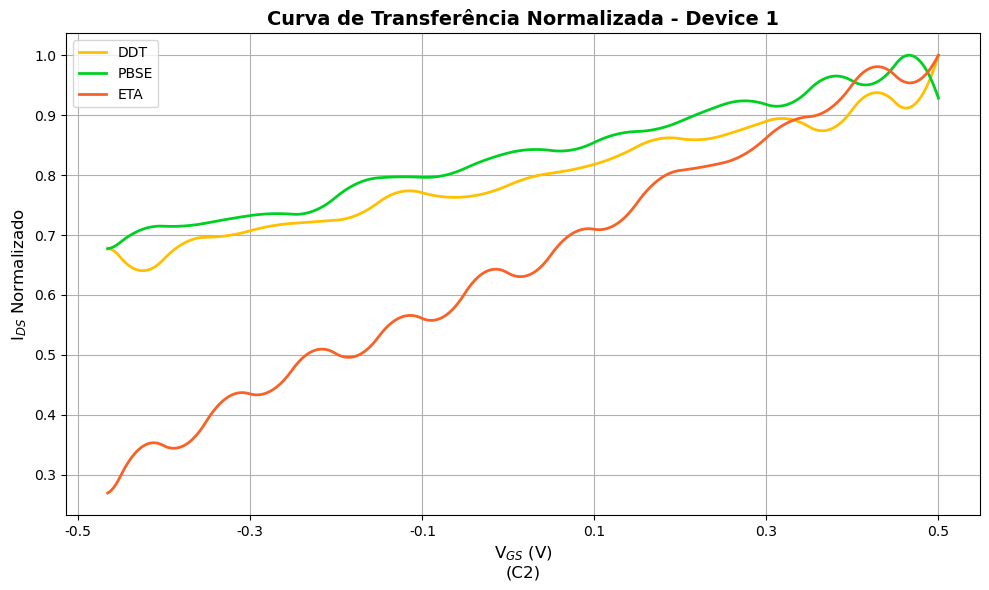

In [17]:
# Exemplo 2: Device individual (absoluta + normalizada) usando df_exec
if not dados_plot_chip:
    raise ValueError('Execute primeiro a célula do Exemplo 1 para reconstruir dados_plot_chip.')

etapa_ref = list(dados_plot_chip.keys())[0]
devices_plot_all = [c for c in dados_plot_chip[etapa_ref].columns if c != 'V_G']
if not devices_plot_all:
    raise ValueError('Nenhum device disponível para plot individual.')

device_exemplo = devices_plot_all[0]

fig = plotter.plot_device_individual(
    dados=dados_plot_chip,
    device=device_exemplo,
    etapas=list(dados_plot_chip.keys()),
    normalizado=False,
    figsize=(10, 6)
)
plt.show()

fig = plotter.plot_device_individual(
    dados=dados_plot_chip,
    device=device_exemplo,
    etapas=list(dados_plot_chip.keys()),
    normalizado=True,
    figsize=(10, 6)
)
plt.show()

In [18]:
# Exemplo 3: Curvas de concentração (se houver no chip) usando df_exec
dados_chip_completo = df_para_dados_plot(df_exec, chip_sel=chip, etapas_sel=None)

concentracoes_disponiveis = [
    c for c in ['menos18', 'menos17', 'menos16', 'menos15', 'menos14', 'menos13',
                'menos12', 'menos11', 'menos10', 'menos9', 'menos8',
                'c10ng', 'c25ng', 'c50ng', 'c75ng', 'c100ng']
    if c in dados_chip_completo
]

if concentracoes_disponiveis:
    fig = plotter.plot_concentracoes(
        dados=dados_chip_completo,
        device=device_exemplo,
        concentracoes=concentracoes_disponiveis[:5],
        incluir_branca=True,
        normalizado=False,
        figsize=(11, 7)
    )
    plt.show()
else:
    print('ℹ️ Não há etapas de concentração disponíveis para este chip.')

ℹ️ Não há etapas de concentração disponíveis para este chip.


## Ajustes rápidos

- Para reproduzir sempre o mesmo caso, fixe manualmente `experimento`, `pasta_dados` e `chip`.
- Para salvar figuras: `plotter.salvar_figura(fig, BASE_CHULHA / 'resultados' / 'nome.png')`.